### 6/23/26 just checking to see if the output is normal

In [33]:
#Packages 
import numpy as np
import xarray as xr
import cmocean.cm as cmo
import matplotlib.pyplot as plt
import mpas_tools

from geometric_features import GeometricFeatures
from geometric_features import read_feature_collection

from mpas_tools.mesh.mask import compute_mpas_region_masks
from mpas_tools.parallel import create_pool
from mpas_tools.io import write_netcdf

import geojson
import json
import mosaic
from xgcm import Grid

In [34]:
filepath = '/pscratch/sd/k/kuyeda/WMT_DVD/bichan/10km/'
ds_output = xr.open_dataset(filepath + '10km_channel_output.nc')
ds_dvd = xr.open_dataset(filepath + 'analysis_members/10km_channel_DVD.0001-01-01.nc')
ds_wmt = xr.open_dataset(filepath + 'analysis_members/10km_channel_WMT_Monthly.0001-01-01.nc')
mesh = xr.open_dataset(filepath + '10km_channel_init.nc')
descriptor = mosaic.Descriptor(mesh, use_latlon=False)

In [35]:
ds_output

<xarray.Dataset> Size: 944MB
Dimensions:                    (Time: 721, nCells: 360, nVertLevels: 50,
                                nVertLevelsP1: 51, nEdges: 1100)
Dimensions without coordinates: Time, nCells, nVertLevels, nVertLevelsP1, nEdges
Data variables: (12/20)
    xtime                      (Time) |S64 46kB ...
    layerThickness             (Time, nCells, nVertLevels) float32 52MB ...
    ssh                        (Time, nCells) float32 1MB ...
    vertDiffTopOfCell          (Time, nCells, nVertLevelsP1) float32 53MB ...
    vertViscTopOfCell          (Time, nCells, nVertLevelsP1) float32 53MB ...
    vertVelocityTop            (Time, nCells, nVertLevelsP1) float32 53MB ...
    ...                         ...
    temperature                (Time, nCells, nVertLevels) float32 52MB ...
    salinity                   (Time, nCells, nVertLevels) float32 52MB ...
    passiveTemperature         (Time, nCells, nVertLevels) float32 52MB ...
    passiveSalinity            (Time, nCells, nVertLevels) float32 52MB ...
    passiveTemperatureSquared  (Time, nCells, nVertLevels) float32 52MB ...
    passiveSalinitySquared     (Time, nCells, nVertLevels) float32 52MB ...
Attributes: (12/1365)
    model_name:                                                      mpas
    core_name:                                                       ocean
    source:                                                          MPAS
    Conventions:                                                     MPAS
    git_version:                                                     unknown
    on_a_sphere:                                                     NO
    ...                                                              ...
    config_rx1_slope_weight:                                         0.1
    config_rx1_zstar_weight:                                         1.0
    config_rx1_horiz_smooth_open_ocean_cells:                        20
    config_rx1_min_levels:                                           3
    config_rx1_min_layer_thickness:                                  1.0
    file_id:                                                         xusiqdesid

In [58]:
ds_wmt.temperatureHorMixTendency.max()

<xarray.DataArray 'temperatureHorMixTendency' ()> Size: 8B
array(0.)

In [37]:
ds_dvd

<xarray.Dataset> Size: 209MB
Dimensions:          (Time: 720, nCells: 360, nVertLevelsP1: 51, nVertLevels: 50)
Dimensions without coordinates: Time, nCells, nVertLevelsP1, nVertLevels
Data variables:
    xtime            (Time) |S64 46kB ...
    chiPhyVerTemp    (Time, nCells, nVertLevelsP1) float32 53MB ...
    chiPhyVerSalt    (Time, nCells, nVertLevelsP1) float32 53MB ...
    chiSpurTempBR08  (Time, nCells, nVertLevels) float32 52MB ...
    chiSpurSaltBR08  (Time, nCells, nVertLevels) float32 52MB ...
Attributes: (12/1365)
    model_name:                                                      mpas
    core_name:                                                       ocean
    source:                                                          MPAS
    Conventions:                                                     MPAS
    git_version:                                                     unknown
    on_a_sphere:                                                     NO
    ...                                                              ...
    config_rx1_slope_weight:                                         0.1
    config_rx1_zstar_weight:                                         1.0
    config_rx1_horiz_smooth_open_ocean_cells:                        20
    config_rx1_min_levels:                                           3
    config_rx1_min_layer_thickness:                                  1.0
    file_id:                                                         cauqtgbg5d

In [38]:
ds_wmt

<xarray.Dataset> Size: 80MB
Dimensions:                                               (Time: 30,
                                                           nCells: 360,
                                                           nVertLevels: 50)
Dimensions without coordinates: Time, nCells, nVertLevels
Data variables: (12/42)
    temperatureTend                                       (Time, nCells, nVertLevels) float64 4MB ...
    salinityTend                                          (Time, nCells, nVertLevels) float64 4MB ...
    temperatureHorizontalAdvectionTendency                (Time, nCells, nVertLevels) float64 4MB ...
    salinityHorizontalAdvectionTendency                   (Time, nCells, nVertLevels) float64 4MB ...
    temperatureVerticalAdvectionTendency                  (Time, nCells, nVertLevels) float64 4MB ...
    salinityVerticalAdvectionTendency                     (Time, nCells, nVertLevels) float64 4MB ...
    ...                                                    ...
    passiveTemperatureSquaredSurfaceFluxSubglacialRunoff  (Time, nCells) float64 86kB ...
    passiveSalinitySquaredSurfaceFluxSubglacialRunoff     (Time, nCells) float64 86kB ...
    passiveTemperatureSurfaceFluxRemoved                  (Time, nCells) float64 86kB ...
    passiveSalinitySurfaceFluxRemoved                     (Time, nCells) float64 86kB ...
    passiveTemperatureSquaredSurfaceFluxRemoved           (Time, nCells) float64 86kB ...
    passiveSalinitySquaredSurfaceFluxRemoved              (Time, nCells) float64 86kB ...
Attributes: (12/1365)
    model_name:                                                      mpas
    core_name:                                                       ocean
    source:                                                          MPAS
    Conventions:                                                     MPAS
    git_version:                                                     unknown
    on_a_sphere:                                                     NO
    ...                                                              ...
    config_rx1_slope_weight:                                         0.1
    config_rx1_zstar_weight:                                         1.0
    config_rx1_horiz_smooth_open_ocean_cells:                        20
    config_rx1_min_levels:                                           3
    config_rx1_min_layer_thickness:                                  1.0
    file_id:                                                         2i7u0xnu5m

In [39]:
ds_wmt.temperatureSurfaceFluxTendency.min()

<xarray.DataArray 'temperatureSurfaceFluxTendency' ()> Size: 8B
array(0.)

In [40]:
for i in ds_wmt.data_vars:
    if 'SurfaceFlux' in i:
        print(i)

temperatureSurfaceFluxTendency
salinitySurfaceFluxTendency
temperatureSurfaceFlux
salinitySurfaceFlux
temperatureSurfaceFluxRunoff
salinitySurfaceFluxRunoff
temperatureSurfaceFluxRemoved
salinitySurfaceFluxRemoved
nonLocalTemperatureSurfaceFlux
nonLocalSalinitySurfaceFlux
passiveTemperatureSurfaceFlux
passiveSalinitySurfaceFlux
passiveTemperatureSquaredSurfaceFlux
passiveSalinitySquaredSurfaceFlux
passiveTemperatureSurfaceFluxRunoff
passiveSalinitySurfaceFluxRunoff
passiveTemperatureSquaredSurfaceFluxRunoff
passiveSalinitySquaredSurfaceFluxRunoff
passiveTemperatureSurfaceFluxSubglacialRunoff
passiveSalinitySurfaceFluxSubglacialRunoff
passiveTemperatureSquaredSurfaceFluxSubglacialRunoff
passiveSalinitySquaredSurfaceFluxSubglacialRunoff
passiveTemperatureSurfaceFluxRemoved
passiveSalinitySurfaceFluxRemoved
passiveTemperatureSquaredSurfaceFluxRemoved
passiveSalinitySquaredSurfaceFluxRemoved


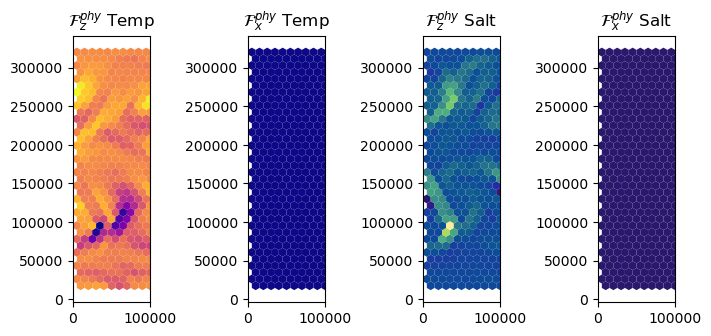

In [41]:
fig,ax = plt.subplots(nrows=1,ncols=4,constrained_layout=True,figsize=(7,12))

mosaic.polypcolor(ax[0],descriptor, ds_wmt.temperatureVertMixTendency.isel(Time=15, nVertLevels=0), cmap='plasma')
mosaic.polypcolor(ax[1],descriptor, ds_wmt.temperatureHorMixTendency.isel(Time=15, nVertLevels=0), cmap='plasma')
mosaic.polypcolor(ax[2],descriptor, ds_wmt.salinityVertMixTendency.isel(Time=15, nVertLevels=1),cmap='cmo.haline')
mosaic.polypcolor(ax[3],descriptor, ds_wmt.salinityHorMixTendency.isel(Time=15, nVertLevels=0),cmap='cmo.haline')
ax[0].set_title(r'$\mathcal{F}^{phy}_{z}$ Temp')
ax[1].set_title(r'$\mathcal{F}^{phy}_{x}$ Temp')
ax[2].set_title(r'$\mathcal{F}^{phy}_{z}$ Salt')
ax[3].set_title(r'$\mathcal{F}^{phy}_{x}$ Salt')

for i in range(0,4):
    ax[i].set_aspect(1.0)

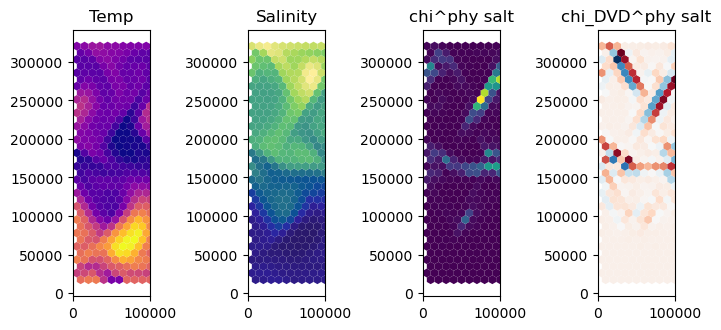

In [42]:
fig,ax = plt.subplots(nrows=1,ncols=4,constrained_layout=True,figsize=(7,12))


#mosaic.polypcolor(ax[0,0], descriptor, region00_plan.isel(Time = time_idx), cmap='RdBu_r', vmin=-cbar_value, vmax=cbar_value)
mosaic.polypcolor(ax[0],descriptor, ds_output.temperature.isel(Time=300, nVertLevels=0), cmap='plasma')
mosaic.polypcolor(ax[1],descriptor, ds_output.salinity.isel(Time=300, nVertLevels=0), cmap='cmo.haline')
mosaic.polypcolor(ax[2],descriptor, ds_dvd.chiPhyVerSalt.isel(Time=300, nVertLevelsP1=1))
mosaic.polypcolor(ax[3],descriptor, ds_dvd.chiSpurSaltBR08.isel(Time=300, nVertLevels=0),cmap='RdBu_r')
ax[0].set_title('Temp')
ax[1].set_title('Salinity')
ax[2].set_title('chi^phy salt')
ax[3].set_title('chi_DVD^phy salt')

for i in range(0,4):
    ax[i].set_aspect(1.0)

In [43]:
for i in ds_wmt.data_vars:
    if 'Mix' in i:
        print(i)

temperatureVertMixTendency
salinityVertMixTendency
temperatureHorMixTendency
salinityHorMixTendency


In [45]:
## SOMETHING IS WRONG I JUST DON'T KNOW WHAT YET

<xarray.DataArray 'salinity' ()> Size: 8B
array(14.1367588)

In [106]:
# calculate the integrand
rho_0 = 1000 # kg/m^3
dV = (mesh.areaCell * mesh.layerThickness).isel(Time=0)
integrand = ds_wmt.salinityVertMixTendency.isel(Time=4) * rho_0 * dV

In [135]:
# define target coords
target_coords = np.arange(14,56,0.75)
dlambda = target_coords[1] - target_coords[0]

# not for this set up, but good practice in case there's topography
# fill the bottom cell with the same value as the one above it (so it is no longer a nan)
ds_output['salinity'] = ds_output.salinity.ffill(dim= 'nVertLevels', limit = 1)

# interpolate data onto nVertLevelsP1 
grid = Grid(ds_output, coords={'Z': {'center': 'nVertLevels', 'outer':'nVertLevelsP1'}}, periodic = False, autoparse_metadata=False)

# interpolate
ds_output['salinity_P1'] = grid.interp(ds_output.salinity, 'Z', boundary='extend')

# transform
ds_output_salinity_mix_tendencyX_transformed = grid.transform(integrand,
                                                             'Z',
                                                             target_coords,
                                                             method= 'conservative',
                                                             target_data = ds_output.salinity_P1.isel(Time=4))

In [143]:
# then calculate the derivative
# create an array
G_phy = np.zeros(len(target_coords))

for i in range(0,len(ds_output.salinity_P1.nVertLevelsP1)-1):
    d_tracerMassFlux = ds_output_salinity_mix_tendencyX_transformed[:,i+1].sum() - ds_output_salinity_mix_tendencyX_transformed[:,i].sum()
    d_tracerMassFlux_dlambda = d_tracerMassFlux / dlambda
    G_phy[i] = d_tracerMassFlux_dlambda
    
    

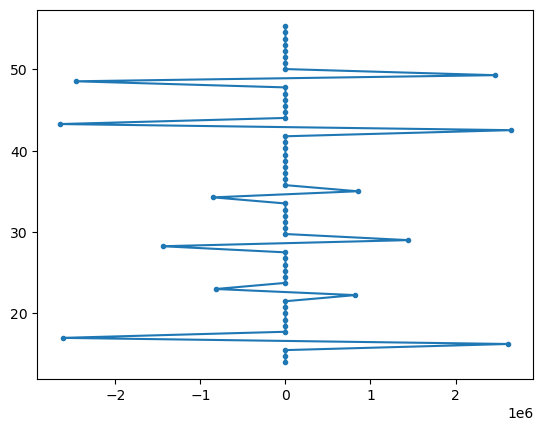

In [149]:
plt.plot(np.cumsum(G_phy), target_coords,marker='.')

In [150]:
np.cumsum(G_phy)

array([-4.40666079e-04, -4.29034755e-04, -9.91240404e-06,  2.62214968e+06,
       -2.62214968e+06, -2.19150912e-04, -4.29035567e-04,  1.89902977e-03,
       -3.38784765e-04, -4.29035567e-04,  8.50206326e-04,  8.21165585e+05,
       -8.21165586e+05, -2.03030335e-03, -4.29035629e-04,  1.53528658e-03,
       -2.35767619e-05, -4.29035629e-04, -6.17754873e-04, -1.44621854e+06,
        1.44621854e+06, -4.54748515e-05, -4.29034951e-04,  7.22349157e-04,
       -9.67385223e-05, -4.29034951e-04, -1.10796814e-03, -8.48421215e+05,
        8.48421216e+05, -3.65756126e-03, -4.29034985e-04, -9.77378993e-04,
       -4.92517126e-03, -4.29034985e-04,  1.44982619e-03,  1.04780193e-03,
       -4.29034985e-04, -5.42701559e-03,  2.65157209e+06, -2.65157209e+06,
       -5.50223561e-03, -4.29035528e-04, -3.47978773e-03, -2.24225973e-03,
       -4.29035528e-04, -1.09222909e-03, -2.46741183e+06,  2.46741182e+06,
        5.02431765e-03, -4.29035625e-04, -4.29035625e-04, -4.29035625e-04,
       -4.29035625e-04, -

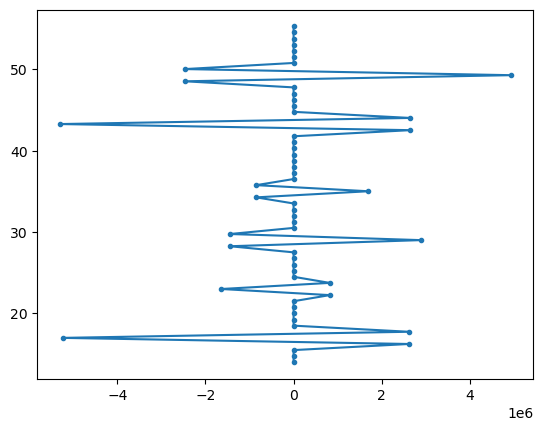

In [147]:
plt.plot(G_phy, target_coords,marker='.')

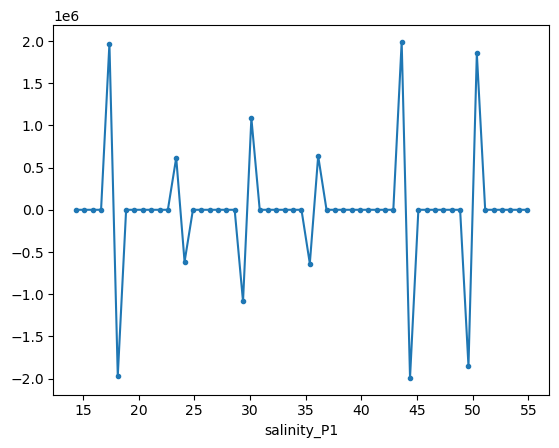

In [105]:
ds_output_salinity_mix_tendencyX_transformed.sum(dim='nCells').plot(marker='.')
# need to multiply by rho to get a mass flux. 
# if this is symmetric about the tendency = 0, does that mean that whatever is mixed out of one isosurface is exactly mixed into the other
# and the mass of each isosurface is constant?
# still need to actually calculate Gphy...

# linear eos ==> namelist has rho_0 = 1000